In [1]:
import sys
sys.path.append('..')
import time
#import torch
import jax
from jax import jit, value_and_grad
import jax.numpy as jnp
import numpy as np
from pathlib import Path
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.utils import generate_random_point_inside_cylinder, generate_random_params
from lucid.detector_params import ParticleParams, isotropic_source
from lucid.losses import compute_simplified_loss
import matplotlib.pyplot as plt
from lucid.AbsorptionSIREN.siren_loader import setup_siren

In [2]:
# when using is_calibration Physics SIREN is not needed (and allows to study the role of Physics SIREN in the time performance).
# change this flag to enable the calculation of the time performance when not using Physics SIREN
CALC_CALIB_PERF = False

In [3]:
# Configuration
default_json_filename = '../config/SK_geom_config.json'
PHYSICS_CONFIG = '../config/SK_physics_config.json'
detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)

siren_model, siren_params = setup_siren('../lucid/AbsorptionSIREN/siren_params.npz')

from lucid.detector_params import load_detector_params, load_physics_config
_default_dp, _, _ = load_physics_config(PHYSICS_CONFIG)
NUM_DETECTORS = len(detector.all_points)

qe_corr = _default_dp.qe_corrections
if qe_corr.ndim == 0:
    qe_corr = jnp.ones(NUM_DETECTORS) * qe_corr

detector_params = _default_dp._replace(
    siren_params=siren_params,
    qe_corrections=qe_corr,
)   

import json

with open(PHYSICS_CONFIG) as f:
    cfg = json.load(f)

print(cfg.keys())

# # Benchmarking parameters
K_VALUES = [8, 12] #[1,2,3,4,5,6,7,8]
N_VALUES = [10000, 100000, 500000]#, 100000 , 250000, 500000, 750000, 1000000, 1500000, 2000000]
WARMUP_RUNS = 10
TIMING_RUNS = 100

def benchmark_simulation(is_calibration=False):
    results = {k: {'N': [], 'mean_time': [], 'std_time': []} for k in K_VALUES}
    print("Benchmarking simulation performance...")

    for K in K_VALUES:
        print(f"\nK = {K}")
        for Nphot in N_VALUES:
            print(f"  N = {Nphot:,}")

            simulate_event = jit(setup_event_simulator(
                default_json_filename, Nphot, temperature=None, K=K,
                is_calibration=is_calibration, max_sensors_per_cell=4,
                physics_config=PHYSICS_CONFIG, default_detector_params=False,
                hit_mode='aggregated', siren_params=siren_params
            ))

            key = jax.random.PRNGKey(42)
            track = ParticleParams(
                energy=jnp.array(800.0, dtype=jnp.float32),
                position=jnp.array([0.0, 0.0, 0.0], dtype=jnp.float32),
                theta=jnp.array(jnp.pi/3, dtype=jnp.float32),
                phi=jnp.array(jnp.pi/4, dtype=jnp.float32),
                t0=jnp.array(0.0, dtype=jnp.float32)
            )

            # Warmup
            for _ in range(WARMUP_RUNS):
                key, subkey = jax.random.split(key)
                source_origin = generate_random_point_inside_cylinder(subkey, r=4, h=6)
                source = isotropic_source(position=source_origin, intensity=1000)
                other_params = source if is_calibration else track

                key, subkey = jax.random.split(key)
                result = simulate_event(other_params, detector_params, subkey)
                jax.tree.map(lambda x: x.block_until_ready(), result)

            # Timing
            times = []
            for _ in range(TIMING_RUNS):
                key, subkey = jax.random.split(key)
                source_origin = generate_random_point_inside_cylinder(subkey, r=4, h=6)
                source = isotropic_source(position=source_origin, intensity=1000)
                other_params = source if is_calibration else track
                key, subkey = jax.random.split(key)
                start = time.time()
                result = simulate_event(other_params, detector_params, subkey)
                jax.tree.map(lambda x: x.block_until_ready(), result)
                times.append(time.time() - start)

            results[K]['N'].append(Nphot)
            results[K]['mean_time'].append(np.mean(times))
            results[K]['std_time'].append(np.std(times))

    return results


def benchmark_gradient(is_calibration=False):
    results = {k: {'N': [], 'mean_time': [], 'std_time': []} for k in K_VALUES}
    print("\n\nBenchmarking gradient computation...")

    Nphot_true = 100000
    key = jax.random.PRNGKey(42)

    source_origin = generate_random_point_inside_cylinder(key, r=4, h=6)
    source = isotropic_source(position=source_origin, intensity=1000)
    track = ParticleParams(
        energy=jnp.array(800.0, dtype=jnp.float32),
        position=jnp.array([0.0, 0.0, 0.0], dtype=jnp.float32),
        theta=jnp.array(jnp.pi/3, dtype=jnp.float32),
        phi=jnp.array(jnp.pi/4, dtype=jnp.float32),
        t0=jnp.array(0.0, dtype=jnp.float32)
    )
    other_params = source if is_calibration else track

    simulate_true = setup_event_simulator(
        default_json_filename, Nphot_true, temperature=None, K=2,
        is_calibration=is_calibration, physics_config=PHYSICS_CONFIG,
        default_detector_params=False, hit_mode='aggregated', siren_params=siren_params
    )
    key, subkey = jax.random.split(key)
    true_data = jax.lax.stop_gradient(simulate_true(other_params, detector_params, subkey))

    for K in K_VALUES:
        print(f"\nK = {K}")
        for Nphot in N_VALUES:
            print(f"  N = {Nphot:,}")

            simulate_event = setup_event_simulator(
                default_json_filename, Nphot, temperature=None, K=K,
                is_calibration=is_calibration, physics_config=PHYSICS_CONFIG,
                default_detector_params=False, hit_mode='aggregated', siren_params=siren_params
            )

            @jit
            def loss_and_grad_fn(dp):
                def loss_fn(dp):
                    simulated_data = simulate_event(other_params, dp, key)
                    return compute_simplified_loss(detector_points, *true_data, *simulated_data, lambda_time=0.0)
                return value_and_grad(loss_fn)(dp)

            # Warmup
            for i in range(WARMUP_RUNS):
                key, subkey = jax.random.split(key)
                source_origin = generate_random_point_inside_cylinder(subkey, r=4, h=6)
                source = isotropic_source(position=source_origin, intensity=1000)
                other_params = source if is_calibration else generate_random_params(key)

                loss_val, grad_val = loss_and_grad_fn(detector_params)
                jax.tree.map(lambda x: x.block_until_ready(), (loss_val, grad_val))
                        
            # Timing
            times = []
            for i in range(TIMING_RUNS):
                key, subkey = jax.random.split(key)
                source_origin = generate_random_point_inside_cylinder(subkey, r=4, h=6)
                source = isotropic_source(position=source_origin, intensity=1000)
                other_params = source if is_calibration else generate_random_params(key)

                start = time.time()
                loss_val, grad_val = loss_and_grad_fn(detector_params)
                jax.tree.map(lambda x: x.block_until_ready(), (loss_val, grad_val))
                times.append(time.time() - start)

            # SIREN gradient (to check that the gradients flow)
            siren_grad_norm = float(jnp.sqrt(sum(
                jnp.sum(g**2) for g in jax.tree.leaves(grad_val.siren_params)
            )))
            print(f"  siren grad norm: {siren_grad_norm:.6e}")

            results[K]['N'].append(Nphot)
            results[K]['mean_time'].append(np.mean(times))
            results[K]['std_time'].append(np.std(times))

    return results

sim_results_full = benchmark_simulation(is_calibration=False)
grad_results_full = benchmark_gradient(is_calibration=False)

print("\n" + "="*50)
print("SUMMARY FULL")
print("="*50)
print("\nSimulation times (milliseconds):")
for K in K_VALUES:
    print(f"\nK = {K}:")
    for i, N in enumerate(sim_results_full[K]['N']):
        mean_ms = sim_results_full[K]['mean_time'][i] * 1000
        std_ms = sim_results_full[K]['std_time'][i] * 1000
        print(f"  N = {N:>9,}: {mean_ms:.2f} ± {std_ms:.2f} ms")

print("\nGradient computation times (milliseconds):")
for K in K_VALUES:
    print(f"\nK = {K}:")
    for i, N in enumerate(grad_results_full[K]['N']):
        mean_ms = grad_results_full[K]['mean_time'][i] * 1000
        std_ms = grad_results_full[K]['std_time'][i] * 1000
        print(f"  N = {N:>9,}: {mean_ms:.2f} ± {std_ms:.2f} ms")

if CALC_CALIB_PERF:
    sim_results_calib = benchmark_simulation(is_calibration=True)
    grad_results_calib = benchmark_gradient(is_calibration=True)
    
    # Print summary
    print("\n" + "="*50)
    print("SUMMARY CALIBRATION")
    print("="*50)
    print("\nSimulation times (milliseconds):")
    for K in K_VALUES:
        print(f"\nK = {K}:")
        for i, N in enumerate(sim_results_calib[K]['N']):
            mean_ms = sim_results_calib[K]['mean_time'][i] * 1000
            std_ms = sim_results_calib[K]['std_time'][i] * 1000
            print(f"  N = {N:>9,}: {mean_ms:.2f} ± {std_ms:.2f} ms")
    
    print("\nGradient computation times (milliseconds):")
    for K in K_VALUES:
        print(f"\nK = {K}:")
        for i, N in enumerate(grad_results_calib[K]['N']):
            mean_ms = grad_results_calib[K]['mean_time'][i] * 1000
            std_ms = grad_results_calib[K]['std_time'][i] * 1000
            print(f"  N = {N:>9,}: {mean_ms:.2f} ± {std_ms:.2f} ms")

[siren_loader] Parameters loaded from ../lucid/AbsorptionSIREN/siren_params.npz
dict_keys(['medium_model', 'qe_curve', 'wall_reflection_rate', 'sensor_reflection_rate', 'qe_corrections'])
Benchmarking simulation performance...

K = 8
  N = 10,000
  N = 100,000


KeyboardInterrupt: 

In [ ]:
import pickle
output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

# Save
if not CALC_CALIB_PERF:
    with open("output/time_benchmark_results.pkl", "wb") as f:
        pickle.dump({
            "sim_results_full": sim_results_full,
            "grad_results_full": grad_results_full,
        }, f)

else:
    with open("output/time_benchmark_results.pkl", "wb") as f:
        pickle.dump({
            "sim_results_full": sim_results_full,
            "grad_results_full": grad_results_full,
            "sim_results_calib": sim_results_calib,
            "grad_results_calib": grad_results_calib
        }, f)

In [5]:
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

import pickle

with open("output/time_benchmark_results.pkl", "rb") as f:
    data = pickle.load(f)

# Access the stored objects:
sim_results_full = data["sim_results_full"]
grad_results_full = data["grad_results_full"]

if CALC_CALIB_PERF:
    sim_results_calib = data["sim_results_calib"]
    grad_results_calib = data["grad_results_calib"]

In [6]:
figures_dir = Path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# Plot results
def plot_results(sim_results, grad_results):
    """Plot both simulation and gradient results"""

    # Use same colors for both plots
    colors = plt.cm.viridis(np.linspace(0, 1, len(K_VALUES)))

    # Simulation timing plot
    plt.figure(figsize=(6, 4))

    for i, K in enumerate(K_VALUES):
        N = np.array(sim_results[K]['N'])
        mean_time = np.array(sim_results[K]['mean_time']) * 1000  # Convert to ms
        std_time = np.array(sim_results[K]['std_time']) * 1000   # Convert to ms

        plt.plot(N, mean_time, 'o-', color=colors[i], label=f'K={K}')
        plt.fill_between(N, mean_time - std_time, mean_time + std_time, alpha=0.3, color=colors[i])

    plt.xlabel('Number of Rays (N)')
    plt.ylabel('Time (ms)')
    plt.title('Prediction Only')
    plt.legend()
    plt.grid(True, alpha=0.3)
    #plt.xscale('log')
    plt.tight_layout()
    plt.savefig('figures/simulation_timing.png', dpi=300)
    plt.show()

    # Gradient timing plot
    plt.figure(figsize=(6, 4))

    for i, K in enumerate(K_VALUES):
        N = np.array(grad_results[K]['N'])
        mean_time = np.array(grad_results[K]['mean_time']) * 1000  # Convert to ms
        std_time = np.array(grad_results[K]['std_time']) * 1000   # Convert to ms

        plt.plot(N, mean_time, 'o-', color=colors[i], label=f'K={K}')
        plt.fill_between(N, mean_time - std_time, mean_time + std_time, alpha=0.3, color=colors[i])

    plt.xlabel('Number of Rays (N)')
    plt.ylabel('Time (ms)')
    plt.title('Prediction and Gradient Calculation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    #plt.xscale('log')
    plt.tight_layout()
    plt.savefig('figures/gradient_timing.pdf')
    plt.show()

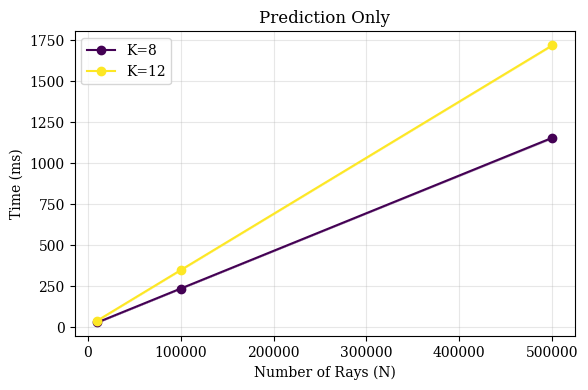

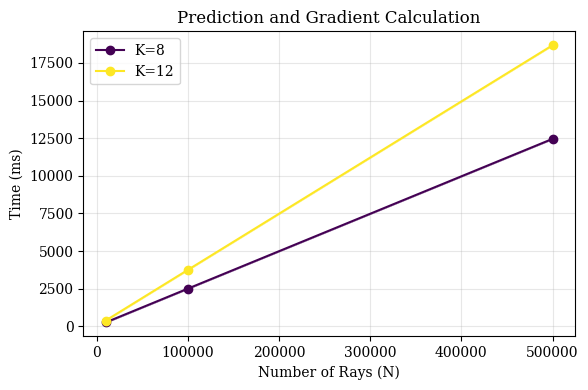

In [7]:
plot_results(sim_results_full, grad_results_full)

In [8]:
if CALC_CALIB_PERF:
    plot_results(sim_results_calib, grad_results_calib)